<a href="https://colab.research.google.com/github/kda5337/Natural-Language-Processing-with-Disaster-Tweets/blob/main/(Edit)KerasNLP_starter_notebook_Disaster_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install keras-core --upgrade
!pip install -q keras-nlp --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 36.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.7 MB/s eta 0:00:00


In [2]:
!pip install -q transformers datasets accelerate evaluate emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 33.3 MB/s eta 0:00:00


In [3]:
import os
import shutil
from google.colab import files

# 기존 Kaggle 인증 폴더 삭제
if os.path.exists("/root/.kaggle"):
    shutil.rmtree("/root/.kaggle")

# 다시 생성
os.makedirs("/root/.kaggle", exist_ok=True)

# 새 kaggle.json 업로드
uploaded = files.upload()

# 업로드된 파일 이름 확인
print(uploaded.keys())

Saving kaggle.json to kaggle.json
dict_keys(['kaggle.json'])


In [4]:
# 잘못 만들어진 access_token 폴더 삭제
!rm -rf ~/.kaggle/access_token

# .kaggle 폴더 생성
!mkdir -p ~/.kaggle

# kaggle.json을 올바른 위치로 복사
!cp kaggle.json ~/.kaggle/kaggle.json

# 권한 설정
!chmod 600 ~/.kaggle/kaggle.json

# 확인
!ls -l ~/.kaggle

total 4
-rw------- 1 root root 64 Jun  2 02:49 kaggle.json


In [5]:
!mkdir -p /content/data/nlp-getting-started

!kaggle competitions download -c nlp-getting-started -p /content/data/nlp-getting-started --force

100% 593k/593k [00:00<00:00, 1.50MB/s]



In [6]:
import zipfile
import os

zip_path = "/content/data/nlp-getting-started/nlp-getting-started.zip"
extract_path = "/content/data/nlp-getting-started"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['test.csv', 'nlp-getting-started.zip', 'sample_submission.csv', 'train.csv']


In [7]:
# This sample uses Keras Core, the multi-backend version of Keras.
# The selected backend is TensorFlow (other supported backends are 'jax' and 'torch')
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

In [8]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import keras_core as keras
import keras_nlp
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn import feature_extraction, linear_model, model_selection, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

Using TensorFlow backend


In [9]:
print("TensorFlow version:", tf.__version__)
print("KerasNLP version:", keras_nlp.__version__)

TensorFlow version: 2.20.0
KerasNLP version: 0.29.1


In [10]:
df_train = pd.read_csv("/content/data/nlp-getting-started/train.csv")
df_test = pd.read_csv("/content/data/nlp-getting-started/test.csv")

print('Training Set Shape = {}'.format(df_train.shape))
print('Training Set Memory Usage = {:.2f} MB'.format(df_train.memory_usage().sum() / 1024**2))
print('Test Set Shape = {}'.format(df_test.shape))
print('Test Set Memory Usage = {:.2f} MB'.format(df_test.memory_usage().sum() / 1024**2))

df_train.head()
df_test.head()

Training Set Shape = (7613, 5)
Training Set Memory Usage = 0.29 MB
Test Set Shape = (3263, 4)
Test Set Memory Usage = 0.10 MB


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [11]:
df_train["length"] = df_train["text"].apply(lambda x : len(x))
df_test["length"] = df_test["text"].apply(lambda x : len(x))

print("Train Length Stat")
print(df_train["length"].describe())
print()

print("Test Length Stat")
print(df_test["length"].describe())

Train Length Stat
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: length, dtype: float64

Test Length Stat
count    3263.000000
mean      102.108183
std        33.972158
min         5.000000
25%        78.000000
50%       109.000000
75%       134.000000
max       151.000000
Name: length, dtype: float64


In [12]:
# Load a DistilBERT model.
preset= "distil_bert_base_en_uncased"

# Use a shorter sequence length.
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(preset,
                                                                   sequence_length=120,
                                                                   name="preprocessor_4_tweets"
                                                                  )

# Pretrained classifier.
classifier = keras_nlp.models.DistilBertClassifier.from_preset(preset,
                                                               preprocessor = preprocessor,
                                                               num_classes=2)

classifier.summary()

Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
BATCH_SIZE = 32
NUM_TRAINING_EXAMPLES = df_train.shape[0]
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.2
STEPS_PER_EPOCH = int(NUM_TRAINING_EXAMPLES)*TRAIN_SPLIT // BATCH_SIZE

EPOCHS = 4
AUTO = tf.data.experimental.AUTOTUNE

X = df_train["text"]
y = df_train["target"]

# For better evaluation, stratify=y added
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VAL_SPLIT, random_state=42, stratify=y)

X_test = df_test["text"]

In [ ]:
# the result of training dataset is not above 0.9 -> change the model;
# There is transformer based pretrained language model called BERTweet.
# Using Bertweet for better accuracy.
# even though i changed the parameters several times, there is no big differences.(Not going above 90)
# since the Bertweet is heavier model than DistilBERT, i will go back to the previous model
'''
import numpy as np
import pandas as pd
import torch
import sys
import datasets
import re

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

datasets.config.TORCHVISION_AVAILABLE = False

def clean_tweet(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "HTTPURL", text)
    text = re.sub(r"@\w+", "@USER", text)
    text = text.replace("&amp;", "&")
    text = re.sub(r"\s+", " ", text).strip()
    return text

X = df_train["text"].apply(clean_tweet)
y = df_train["target"]
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2,
    random_state=SEED,
    stratify=y
)
X_test = df_test["text"].apply(clean_tweet)

MODEL_NAME = "vinai/bertweet-base"
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, use_fast=False, normalization=True)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2)

# DataFrame -> Hugging Face Dataset
train_df_for_hf = pd.DataFrame({
    "text": X_train.values, "labels": y_train.values})

val_df_for_hf = pd.DataFrame({
    "text": X_val.values, "labels": y_val.values })

test_df_for_hf = pd.DataFrame({
    "text": X_test.values})

train_dataset = Dataset.from_pandas(train_df_for_hf, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df_for_hf, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df_for_hf, preserve_index=False)

# 6. Tokenization
MAX_LENGTH = 128

def tokenize_function(examples):
    return tokenizer(
        examples["text"], padding="max_length",
        truncation=True, max_length=MAX_LENGTH)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    return {
        "accuracy": accuracy, "precision": precision,
        "recall": recall, "f1": f1}

# TrainingArguments
EPOCHS = 4
BATCH_SIZE = 16

training_args = TrainingArguments(
    output_dir="./bertweet-disaster-results",

    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,

    weight_decay=0.01,
    warmup_ratio=0.1,

    logging_dir="./logs",
    logging_steps=50,
    report_to="none",

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,

    fp16=torch.cuda.is_available()
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)
trainer.train()

# Evaluation
eval_results = trainer.evaluate()

print("Validation Accuracy:", round(eval_results["eval_accuracy"], 4))
print("Validation Precision:", round(eval_results["eval_precision"], 4))
print("Validation Recall:", round(eval_results["eval_recall"], 4))
print("Validation F1 Score:", round(eval_results["eval_f1"], 4))
'''

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Validation Accuracy: 0.8536
Validation Precision: 0.8459
Validation Recall: 0.8058
Validation F1 Score: 0.8254


In [14]:
# Compile
# There was no big changes of chaning the epoches and batch
# Therefore, I am changing the optimizer models => AdamW
classifier.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-5),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

# Fit
history = classifier.fit(x=X_train,
                         y=y_train,
                         batch_size=BATCH_SIZE,
                         epochs=EPOCHS,
                         validation_data=(X_val, y_val)
                        )

Epoch 1/4
191/191 ━━━━━━━━━━━━━━━━━━━━ 156s 525ms/step - accuracy: 0.7993 - loss: 0.4556 - val_accuracy: 0.8332 - val_loss: 0.3876
Epoch 2/4
191/191 ━━━━━━━━━━━━━━━━━━━━ 78s 407ms/step - accuracy: 0.8614 - loss: 0.3461 - val_accuracy: 0.8411 - val_loss: 0.3795
Epoch 3/4
191/191 ━━━━━━━━━━━━━━━━━━━━ 81s 425ms/step - accuracy: 0.8972 - loss: 0.2789 - val_accuracy: 0.8444 - val_loss: 0.4086
Epoch 4/4
191/191 ━━━━━━━━━━━━━━━━━━━━ 77s 404ms/step - accuracy: 0.9227 - loss: 0.2258 - val_accuracy: 0.8201 - val_loss: 0.5095


191/191 ━━━━━━━━━━━━━━━━━━━━ 28s 135ms/step


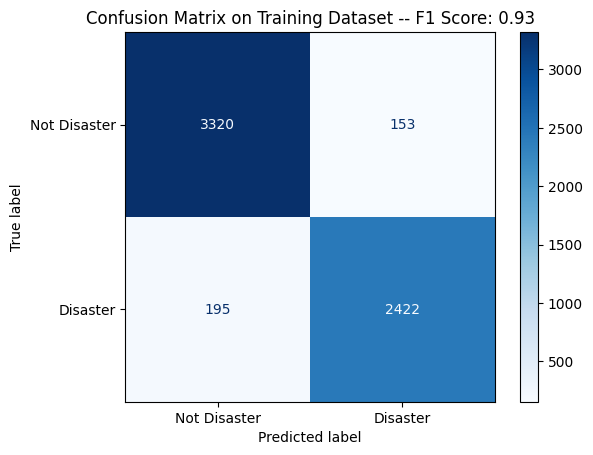

In [15]:
def displayConfusionMatrix(y_true, y_pred, dataset):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        np.argmax(y_pred, axis=1),
        display_labels=["Not Disaster","Disaster"],
        cmap=plt.cm.Blues
    )

    tn, fp, fn, tp = confusion_matrix(y_true, np.argmax(y_pred, axis=1)).ravel()
    f1_score = tp / (tp+((fn+fp)/2))

    disp.ax_.set_title("Confusion Matrix on " + dataset + " Dataset -- F1 Score: " + str(f1_score.round(2)))

y_pred_train = classifier.predict(X_train)
displayConfusionMatrix(y_train, y_pred_train, "Training")

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step


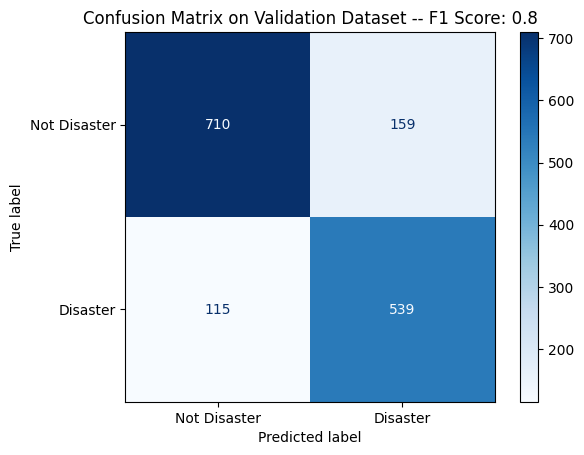

In [16]:
y_pred_val = classifier.predict(X_val)
displayConfusionMatrix(y_val, y_pred_val, "Validation")

In [17]:
sample_submission = pd.read_csv("/content/data/nlp-getting-started/sample_submission.csv")
sample_submission.head()

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0


In [18]:
sample_submission["target"] = np.argmax(classifier.predict(X_test), axis=1)
sample_submission.describe()
sample_submission.to_csv("submission.csv", index=False)

102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step


In [19]:
def analyze_fp_fn(X_text, y_true, y_pred, dataset="Validation", n=10):
    # logits -> probability -> label
    y_prob = tf.nn.softmax(y_pred, axis=1).numpy()
    y_label = np.argmax(y_prob, axis=1)


    df_error = pd.DataFrame({
        "text": pd.Series(X_text).reset_index(drop=True),
        "actual": pd.Series(y_true).reset_index(drop=True),
        "predicted": y_label,
        "prob_not_disaster": y_prob[:, 0],
        "prob_disaster": y_prob[:, 1]})

    df_error["actual_label"] = df_error["actual"].map({
        0: "Not Disaster",
        1: "Disaster"})

    df_error["predicted_label"] = df_error["predicted"].map({
        0: "Not Disaster",
        1: "Disaster"})

    # FP / FN
    fp = df_error[(df_error["actual"] == 0) & (df_error["predicted"] == 1)].copy()
    fn = df_error[(df_error["actual"] == 1) & (df_error["predicted"] == 0)].copy()

    # confidence
    fp["confidence"] = fp["prob_disaster"]
    fn["confidence"] = fn["prob_not_disaster"]

    fp = fp.sort_values("confidence", ascending=False)
    fn = fn.sort_values("confidence", ascending=False)

    print(f"\n[{dataset} FP/FN Analysis]")
    print("Confusion Matrix:")
    print(confusion_matrix(df_error["actual"], df_error["predicted"]))

    print("\nClassification Report:")
    print(classification_report(
        df_error["actual"],
        df_error["predicted"],
        target_names=["Not Disaster", "Disaster"],
        zero_division=0))

    print("False Positive count:", len(fp))
    print("False Negative count:", len(fn))

    print("\nFalse Positive Examples")
    display(fp[[ "text", "actual_label", "predicted_label",
        "prob_disaster", "confidence"]].head(n))

    print("\nFalse Negative Examples")
    display(fn[[ "text", "actual_label", "predicted_label",
        "prob_not_disaster", "confidence"]].head(n))

    return df_error, fp, fn

In [20]:
analysis_df_val, false_positive_val, false_negative_val = analyze_fp_fn(
    X_text=X_val,
    y_true=y_val,
    y_pred=y_pred_val,
    dataset="Validation",
    n=10
)


[Validation FP/FN Analysis]
Confusion Matrix:
[[710 159]
 [115 539]]

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.86      0.82      0.84       869
    Disaster       0.77      0.82      0.80       654

    accuracy                           0.82      1523
   macro avg       0.82      0.82      0.82      1523
weighted avg       0.82      0.82      0.82      1523

False Positive count: 159
False Negative count: 115

False Positive Examples


,text,actual_label,predicted_label,prob_disaster,confidence
585,Survival Kit Whistle Fire Starter Wire Saw Cre...,Not Disaster,Disaster,0.995992,0.995992
1292,Reusing advanced in life equipments in transit...,Not Disaster,Disaster,0.995814,0.995814
562,Google Alert: Emergency units simulate a chemi...,Not Disaster,Disaster,0.995743,0.995743
1127,Family mourns drowning of 'superhero' toddler ...,Not Disaster,Disaster,0.994317,0.994317
34,@TroySlaby22 slicker than an oil spill,Not Disaster,Disaster,0.994302,0.994302
742,Trafford Centre film fans angry after Odeon ci...,Not Disaster,Disaster,0.994132,0.994132
183,A staged locomotive wreck what could possibly ...,Not Disaster,Disaster,0.994004,0.994004
656,World Annihilation vs Self Transformation http...,Not Disaster,Disaster,0.993636,0.993636
525,.POTUS #StrategicPatience is a strategy for #G...,Not Disaster,Disaster,0.993559,0.993559
851,Dr. Jim &amp; the tsunami: The latest New York...,Not Disaster,Disaster,0.993146,0.993146



False Negative Examples


,text,actual_label,predicted_label,prob_not_disaster,confidence
81,@leedsrouge Love what you picked! We're playin...,Disaster,Not Disaster,0.984054,0.984054
780,Until my death I'll forever rep the Jets.,Disaster,Not Disaster,0.981859,0.981859
1132,Why are you deluged with low self-image? Take ...,Disaster,Not Disaster,0.980424,0.980424
806,@_chelsdelong12 @kendra_leigh13 I'll crash it,Disaster,Not Disaster,0.980142,0.980142
968,Ina Buted Girl Crush??,Disaster,Not Disaster,0.980067,0.980067
791,Do you feel like you are sinking in low self-i...,Disaster,Not Disaster,0.979542,0.979542
793,I just checked in! ÛÒ at On Fire on @ZomatoAU...,Disaster,Not Disaster,0.979524,0.979524
448,@Stretcher @witter @Rexyy @Towel show me a pic...,Disaster,Not Disaster,0.979068,0.979068
7,I can't drown my demons they know how to swim,Disaster,Not Disaster,0.978650,0.978650
922,Keep shape your shoes ??#Amazon #foot #adjust ...,Disaster,Not Disaster,0.976109,0.976109


In [22]:
#This is file preprocessing of GitHub Push
from google.colab import drive
from pathlib import Path
import json
import shutil

drive.mount('/content/drive')

from pathlib import Path

notebook_name = "(Edit)KerasNLP starter notebook Disaster Tweets"

matches = list(Path("/content/drive/MyDrive").rglob(notebook_name))

for path in matches:
    print(path)

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/(Edit)KerasNLP starter notebook Disaster Tweets


In [23]:
target_path = Path("/content/drive/MyDrive/Colab Notebooks/(Edit)KerasNLP starter notebook Disaster Tweets")

backup_path = target_path.with_suffix(".backup.ipynb")
shutil.copy2(target_path, backup_path)

with open(target_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

notebook.get("metadata", {}).pop("widgets", None)

with open(target_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, ensure_ascii=False, indent=1)

print("수정 완료:", target_path)
print("백업 저장:", backup_path)

수정 완료: /content/drive/MyDrive/Colab Notebooks/(Edit)KerasNLP starter notebook Disaster Tweets
백업 저장: /content/drive/MyDrive/Colab Notebooks/(Edit)KerasNLP starter notebook Disaster Tweets.backup.ipynb
